=== PLOTTING ELECTRON GRAPHS ===


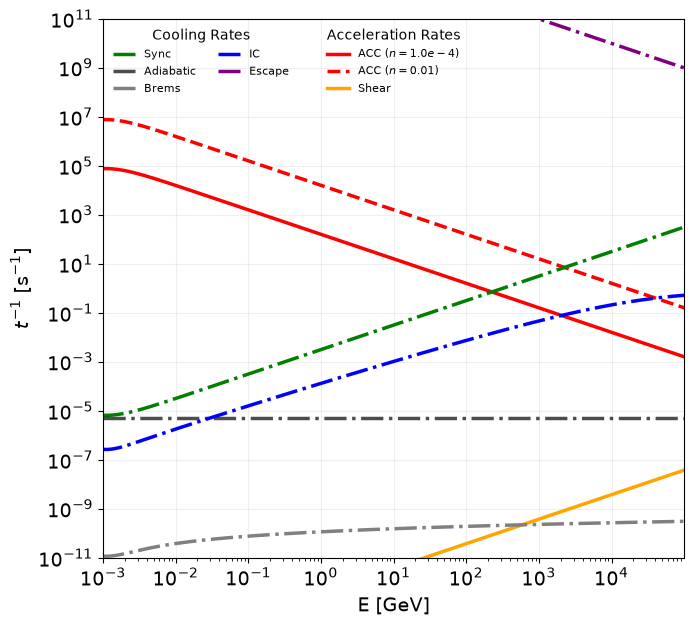

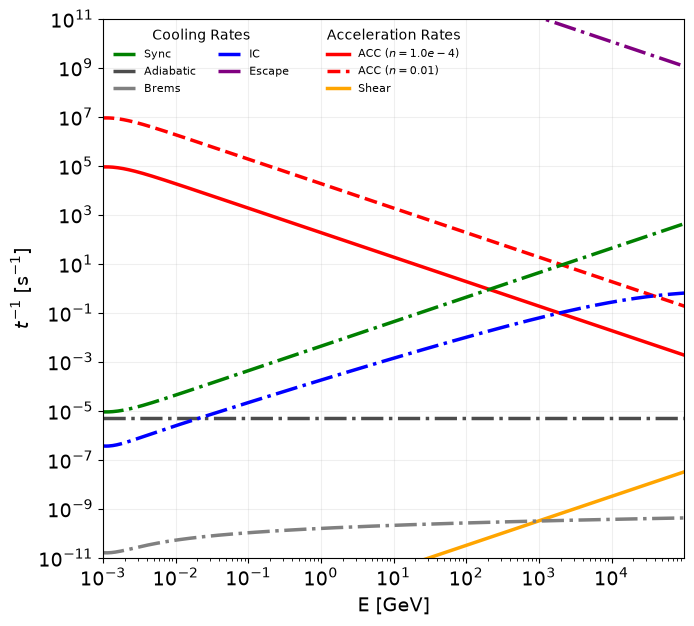

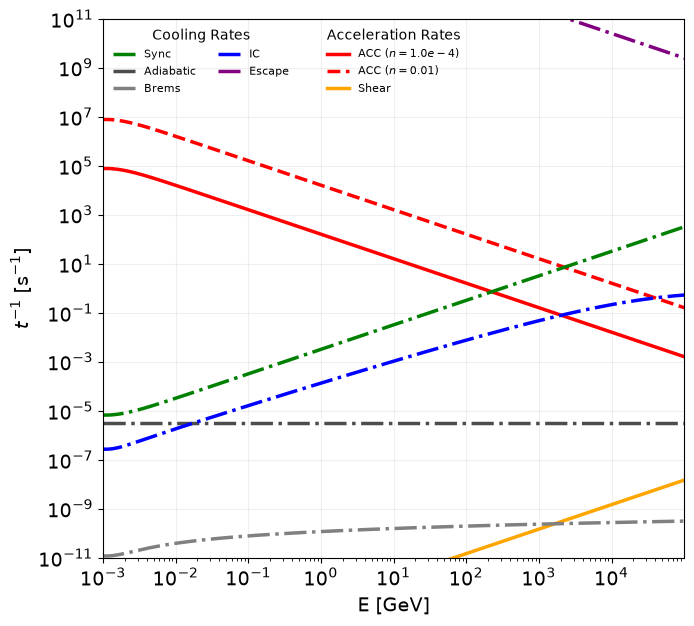

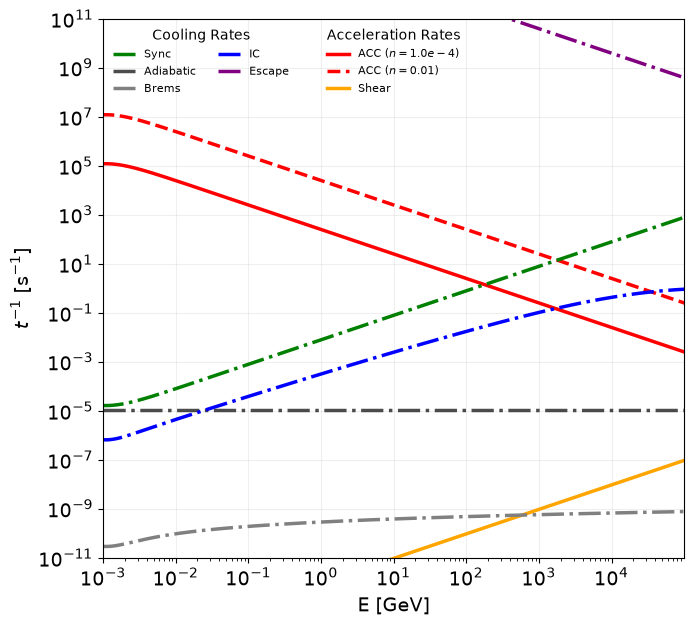

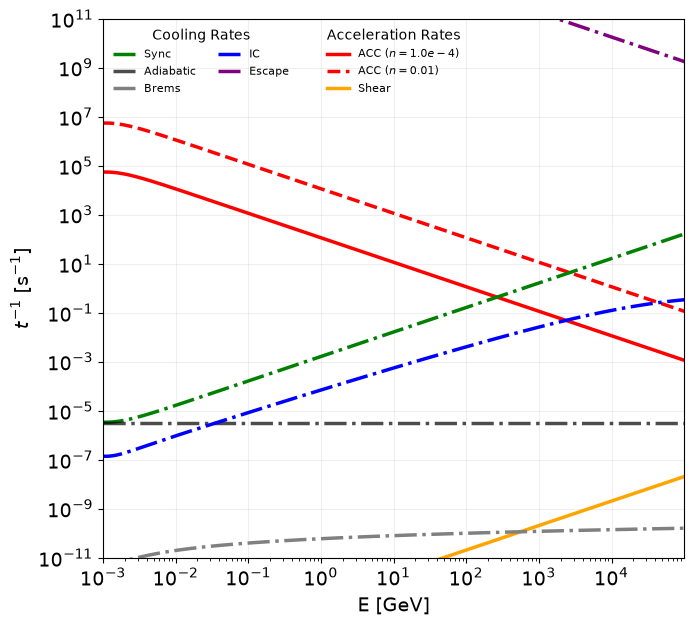

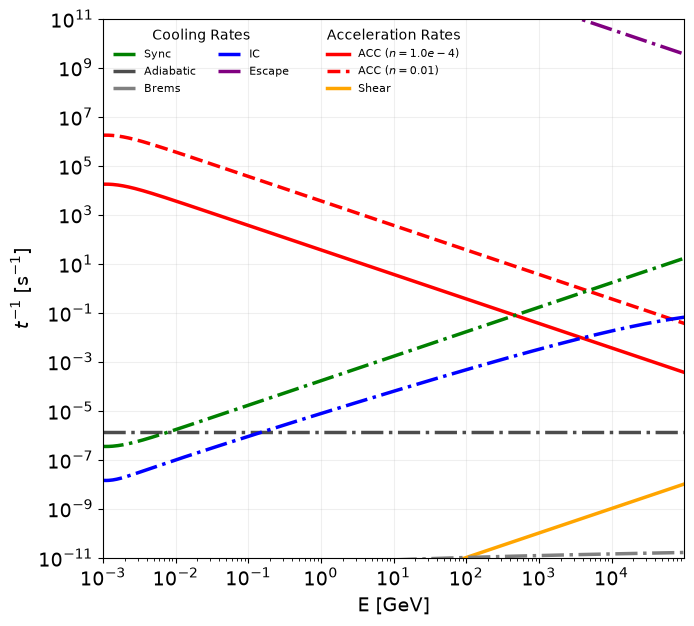

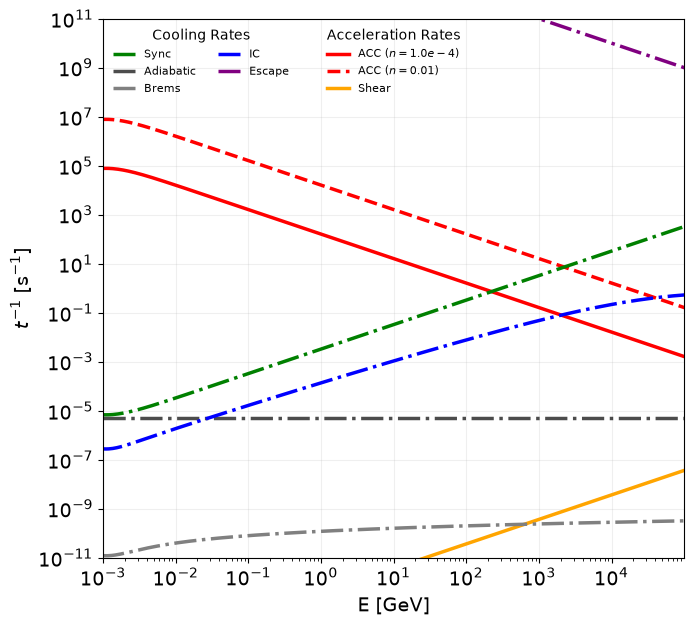

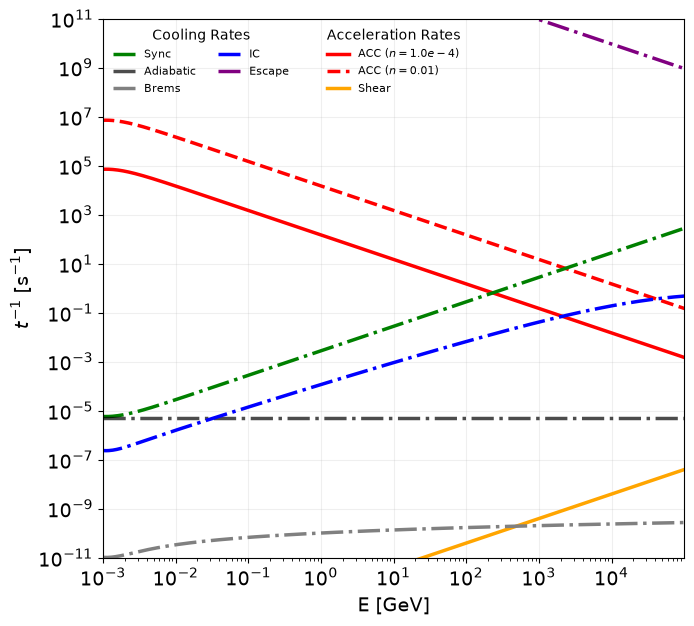

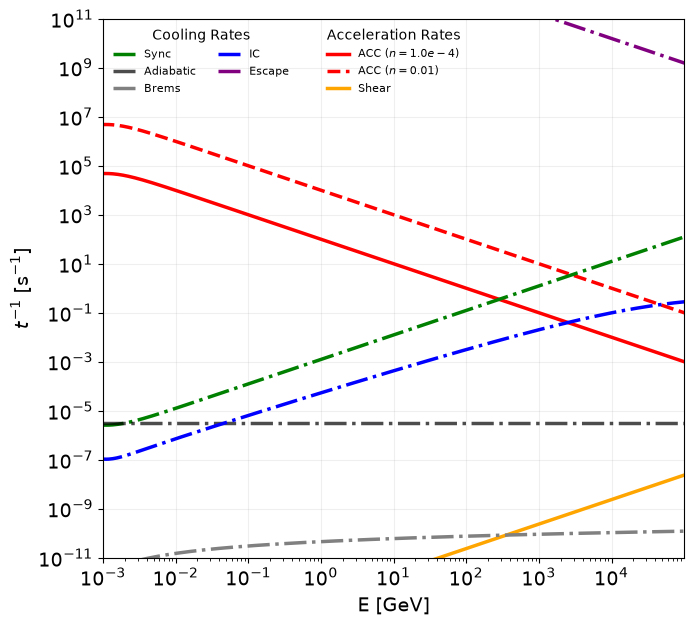

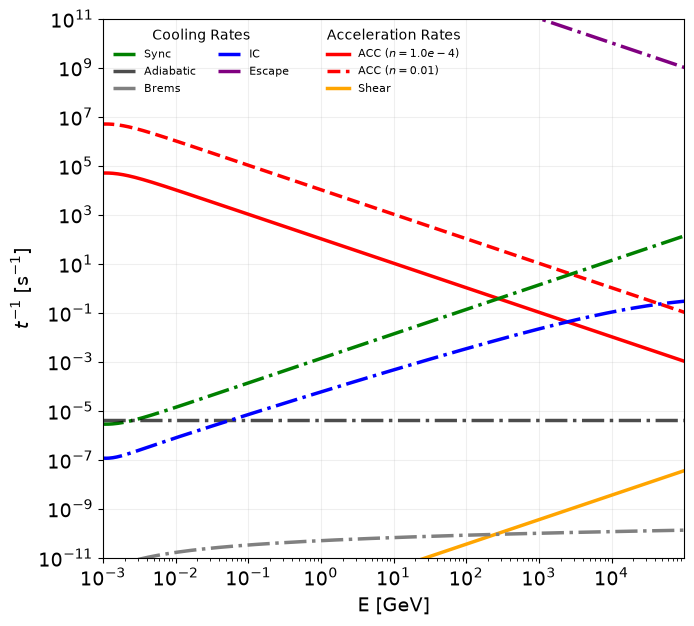

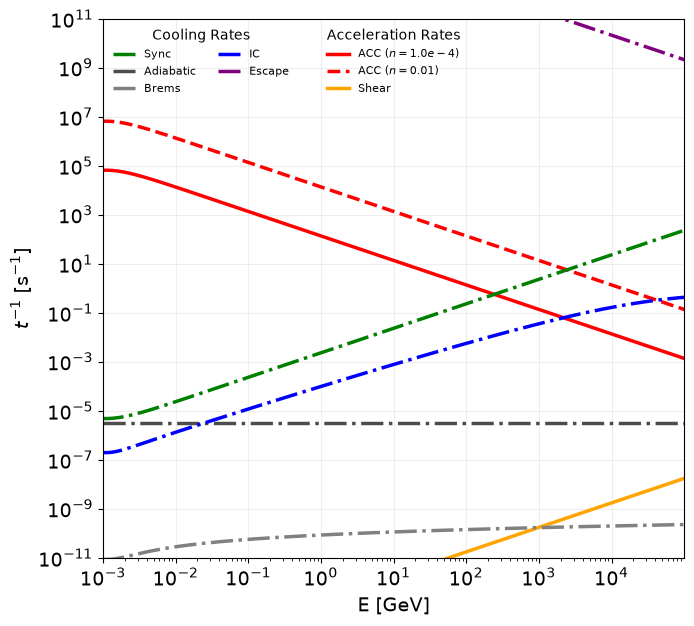

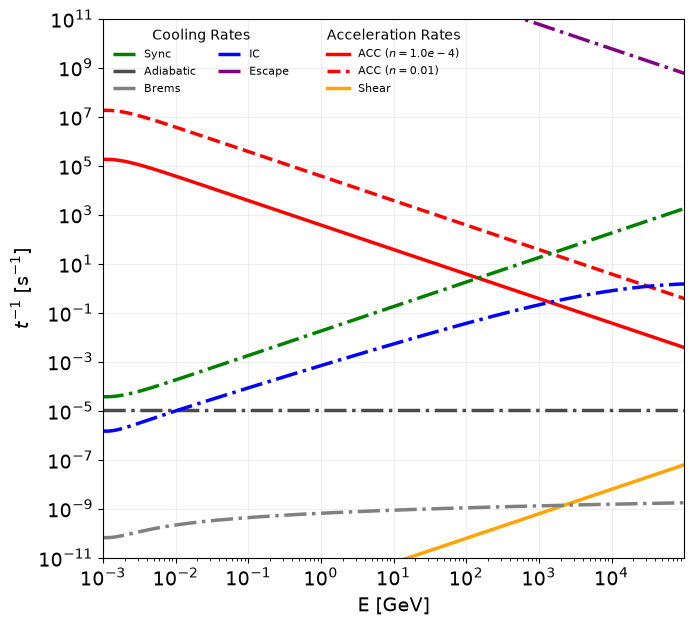

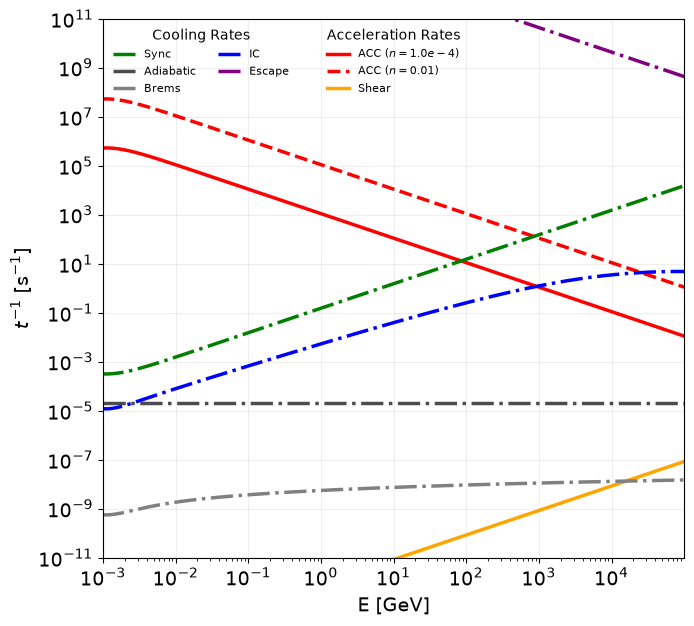

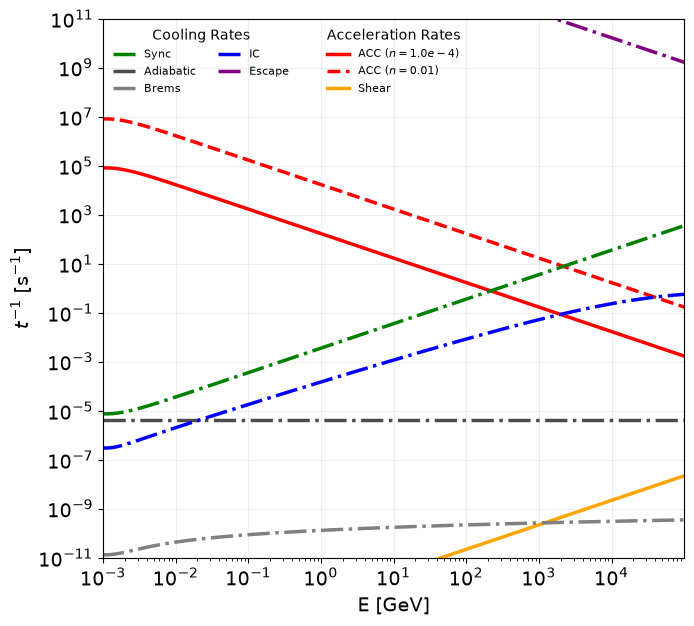

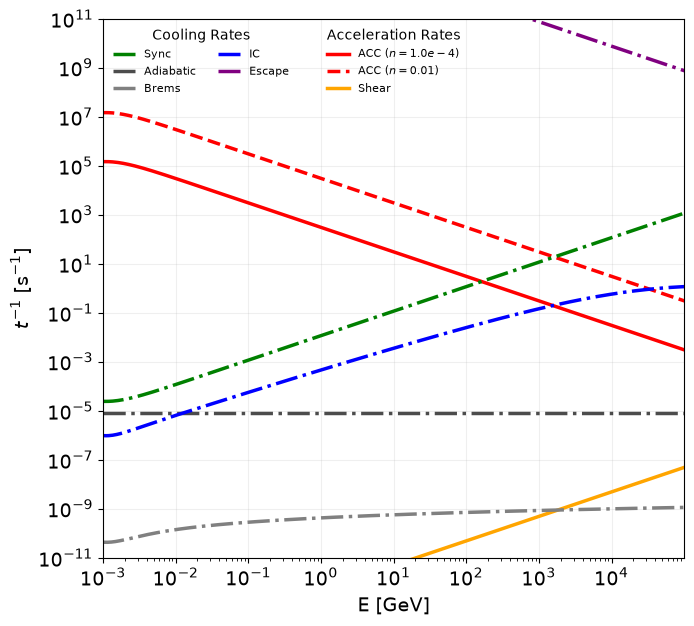

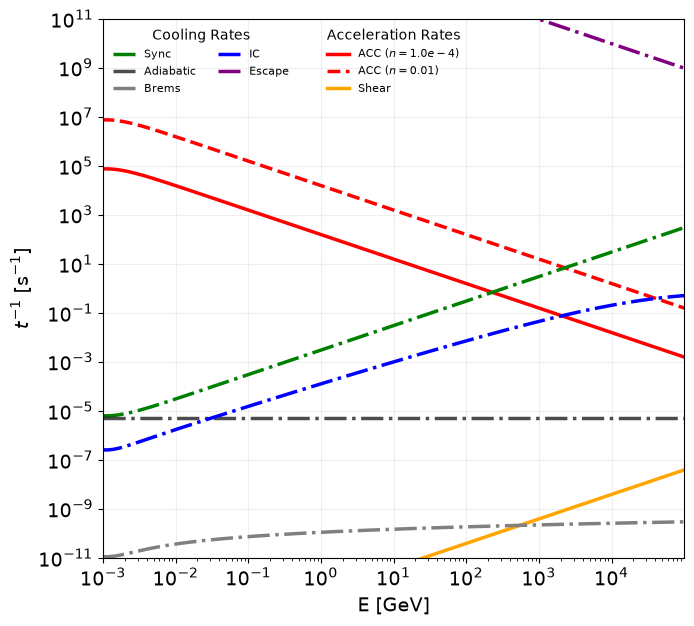

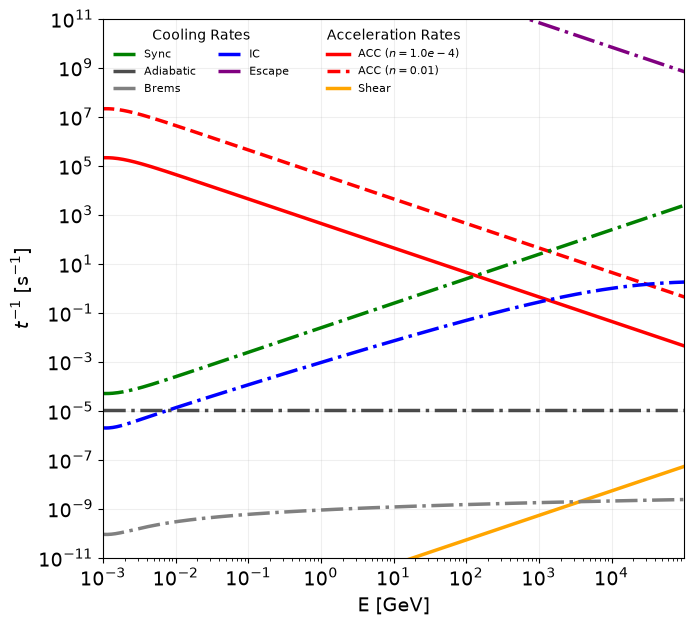

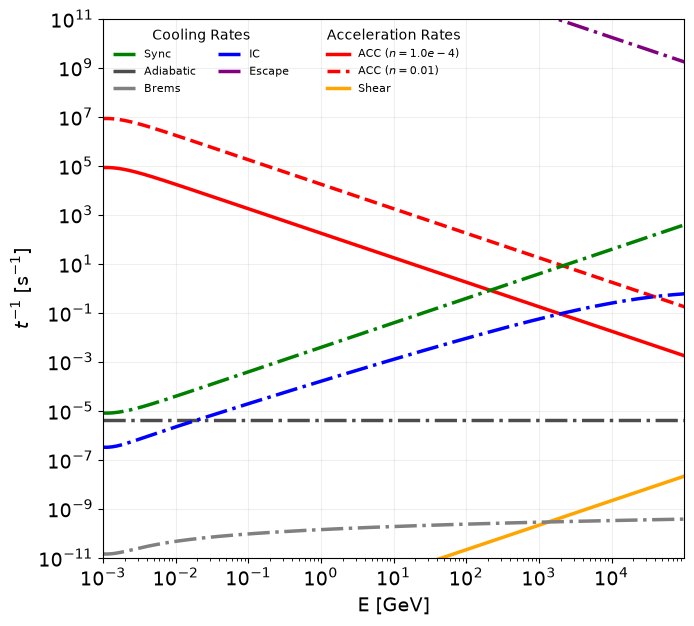

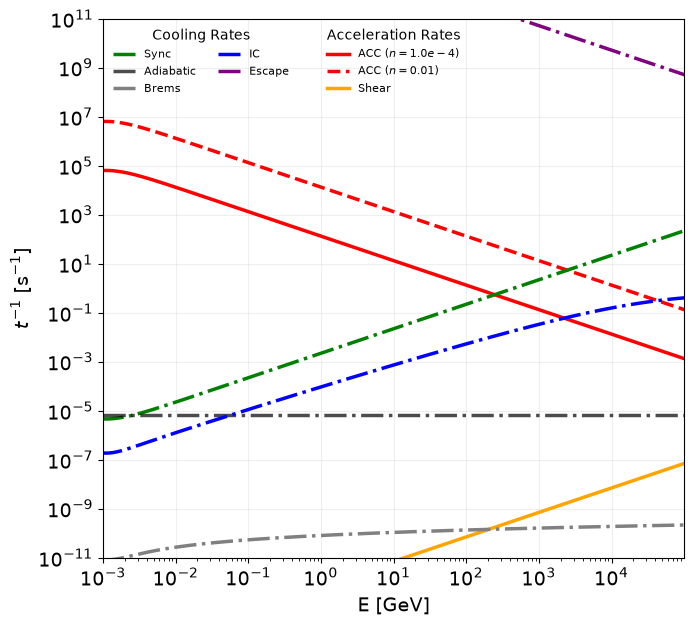

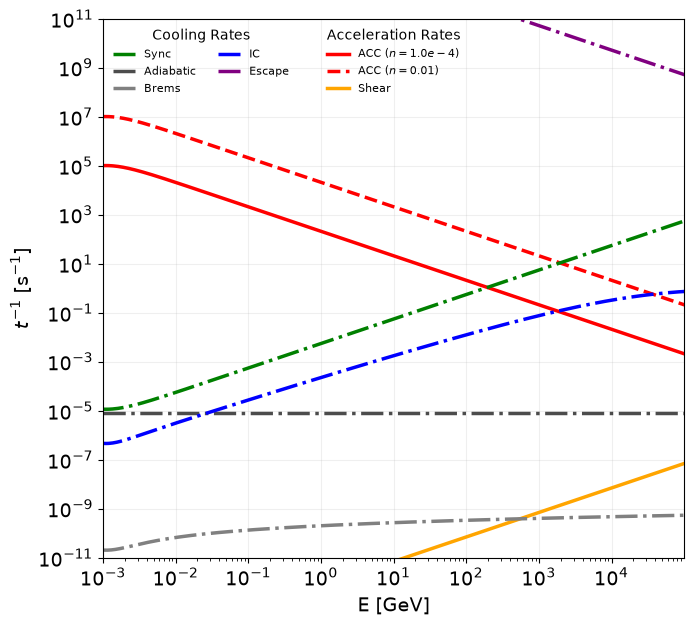

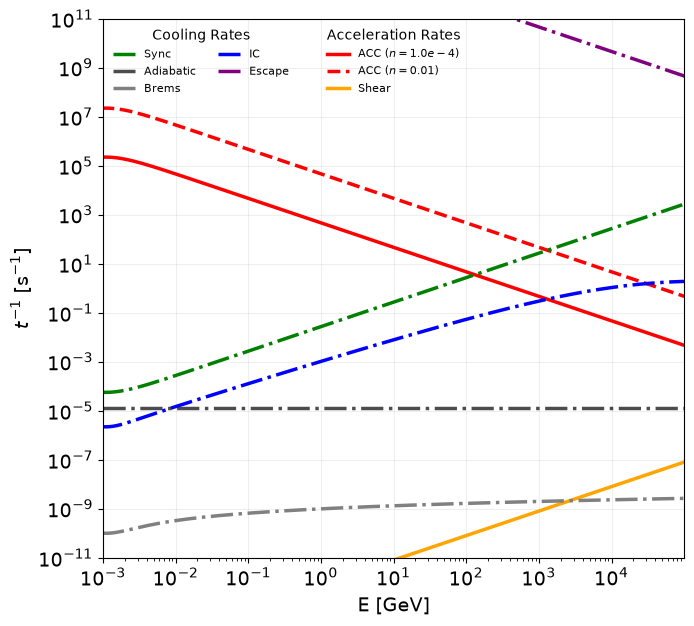

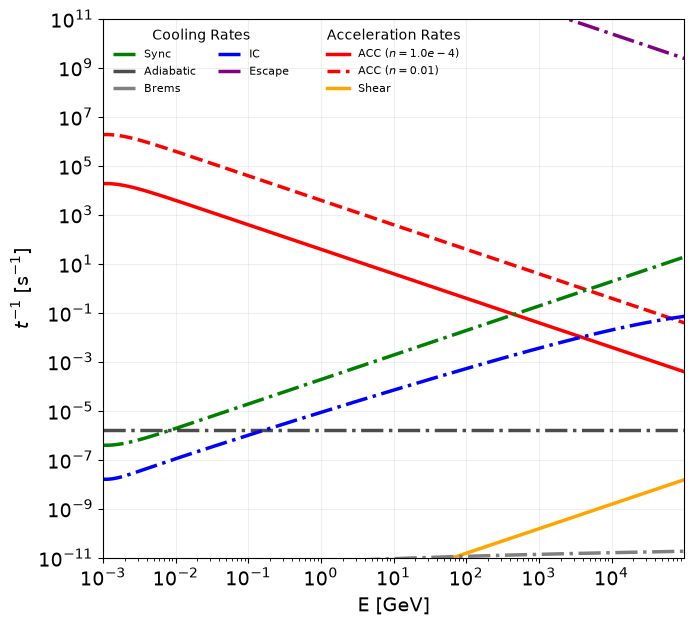

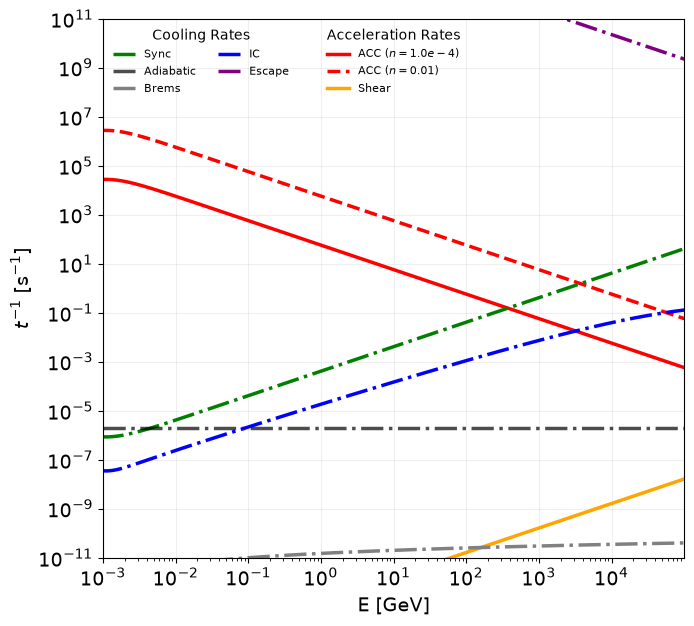

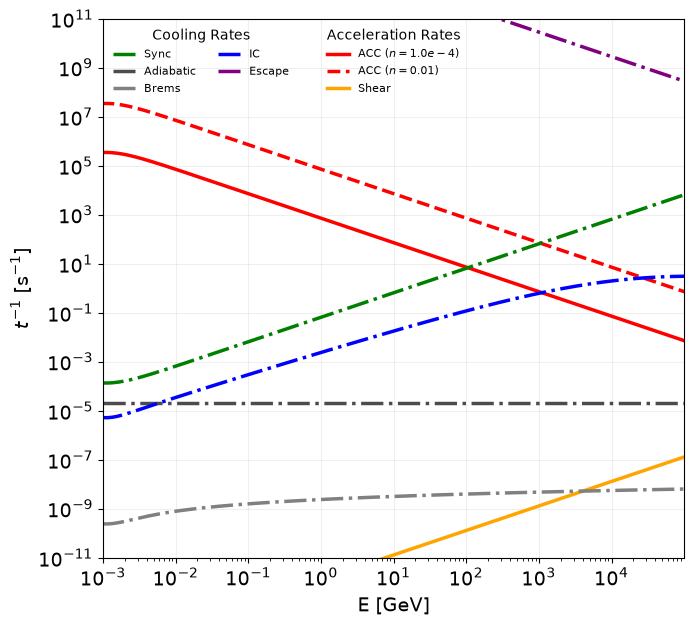

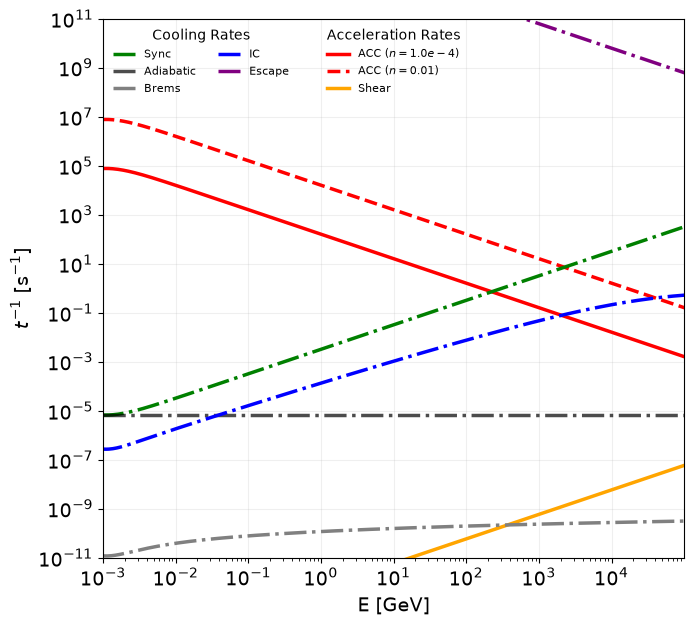

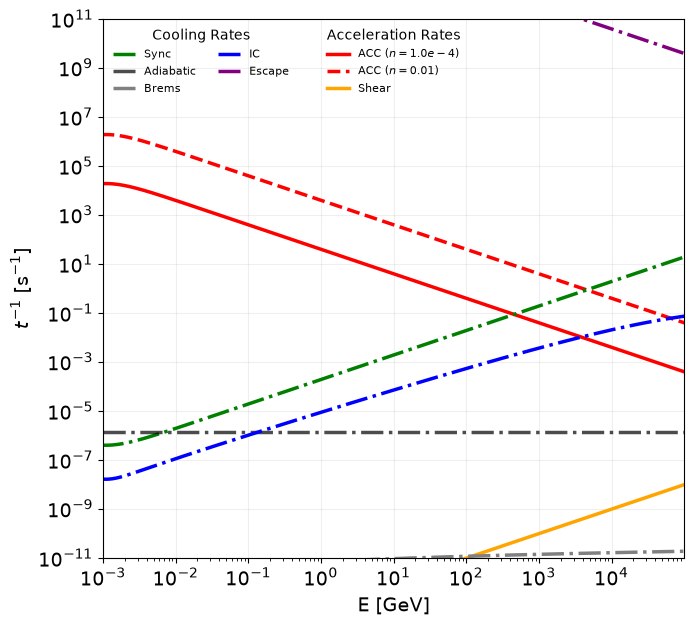

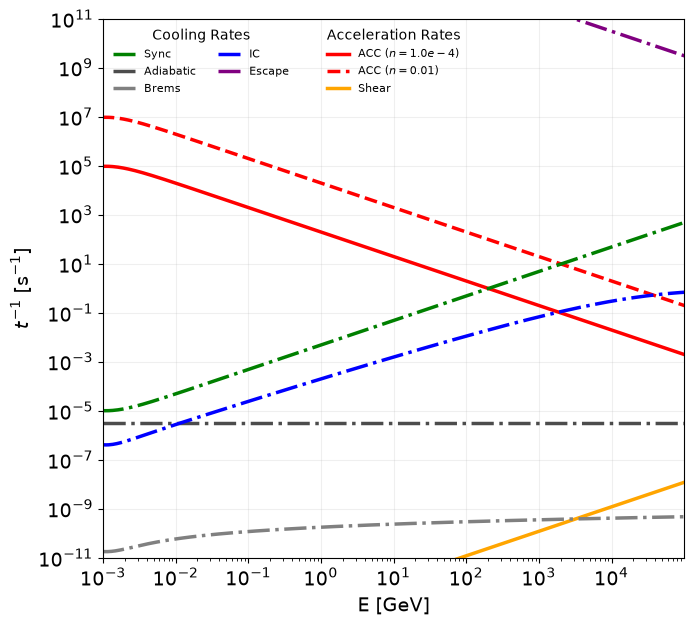

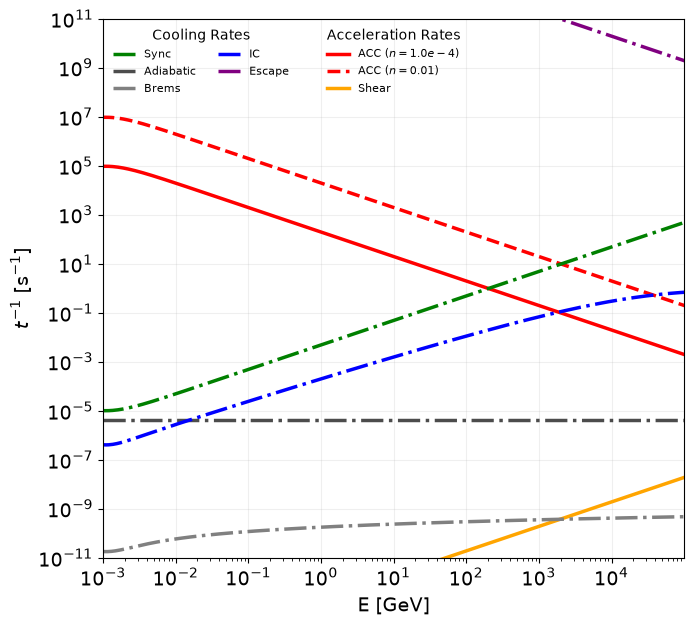

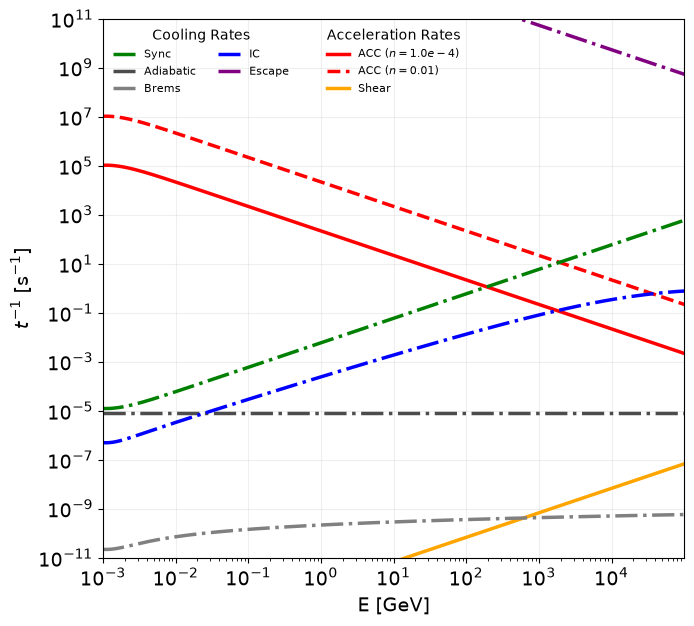

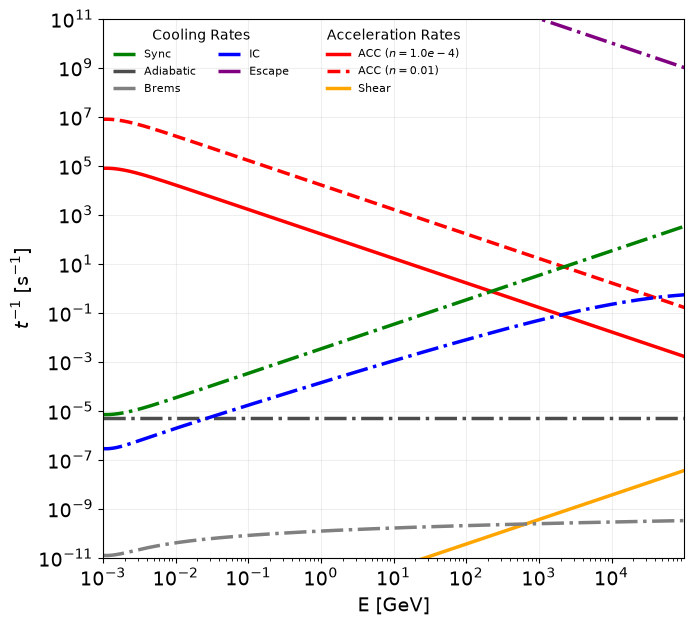

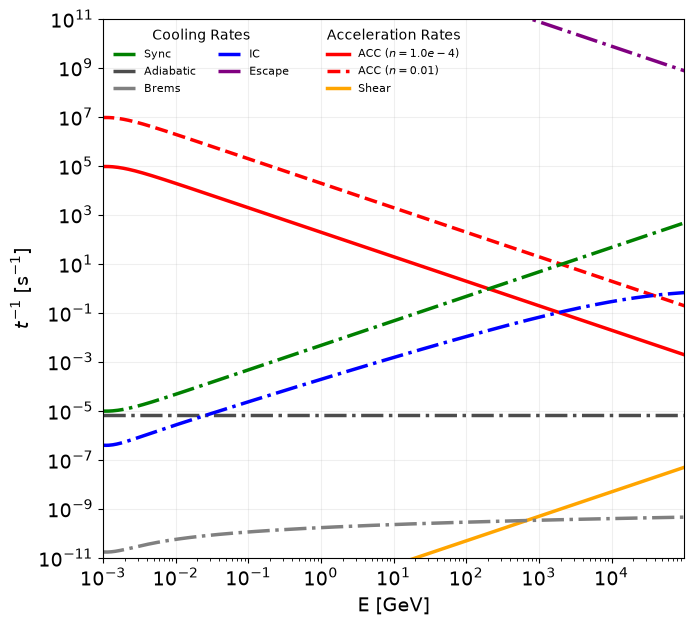

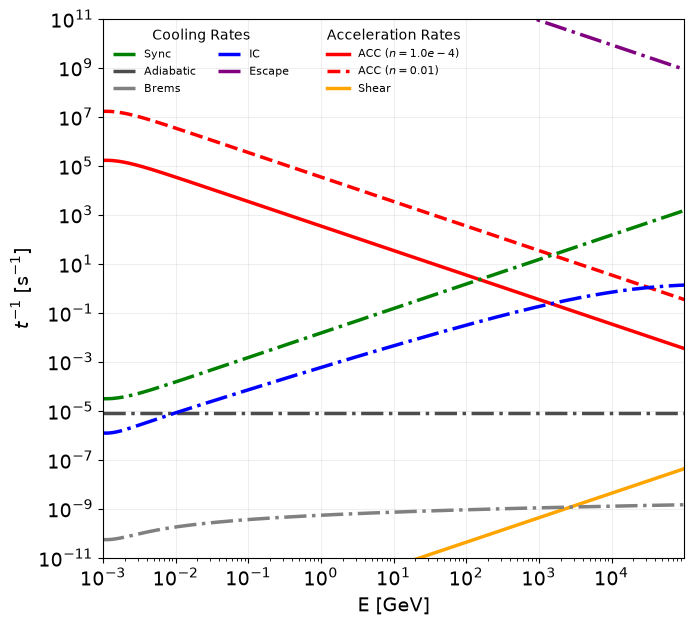

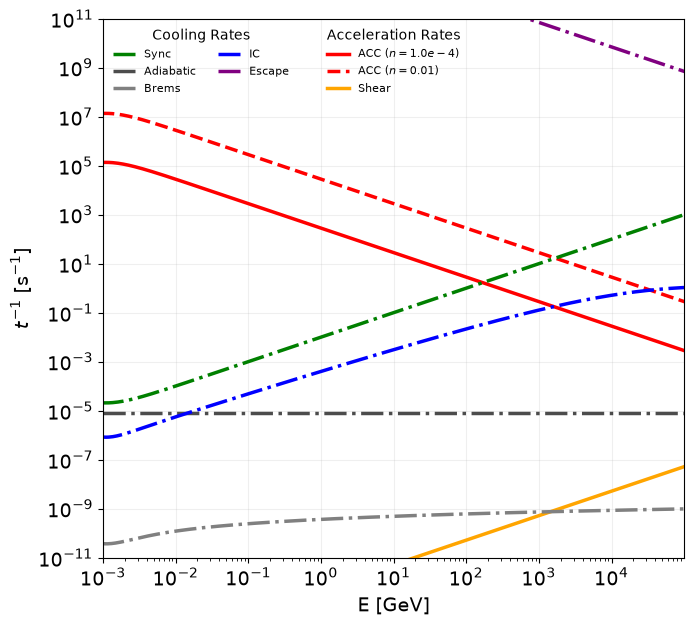

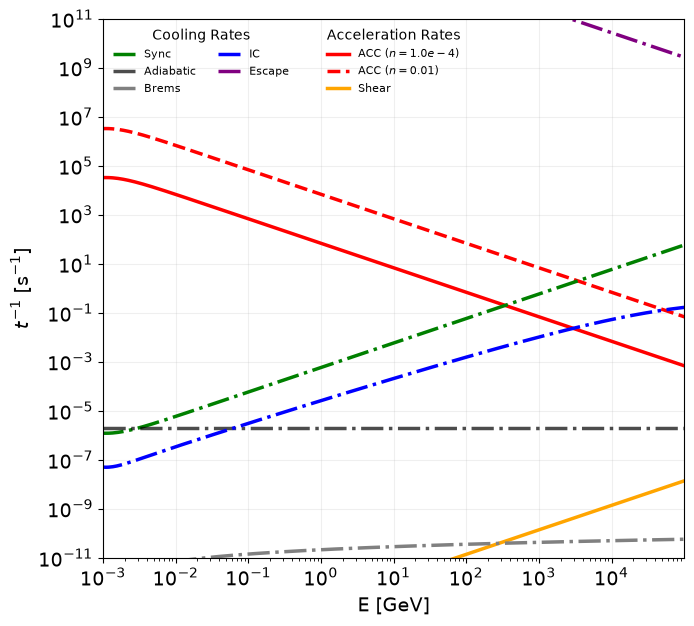

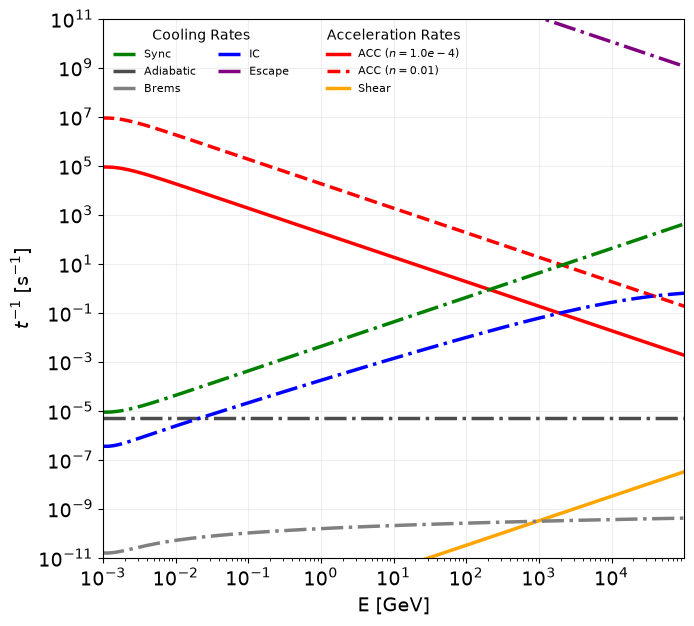

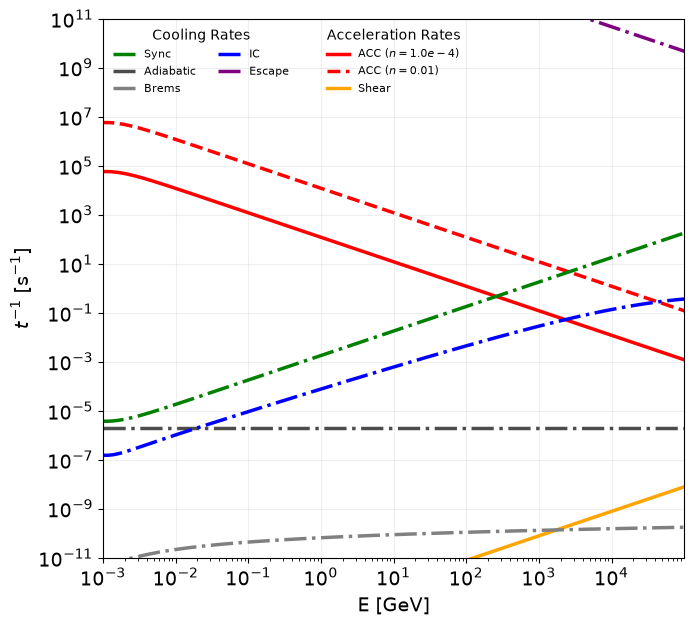

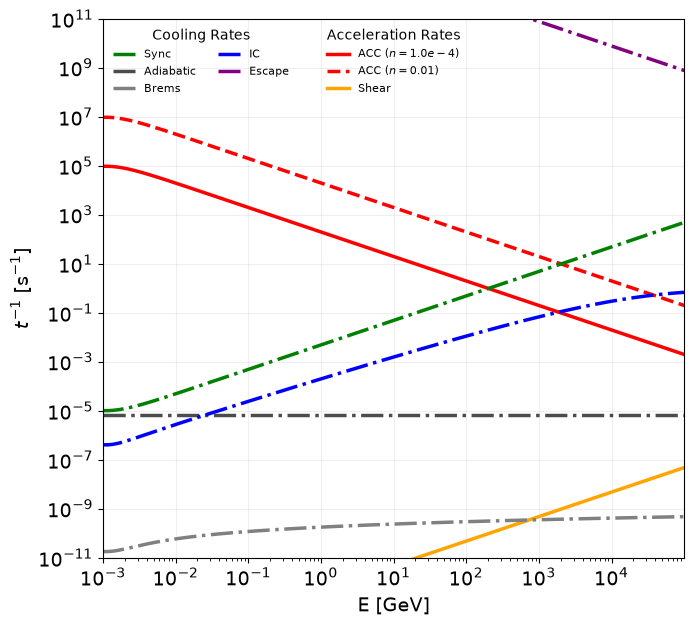

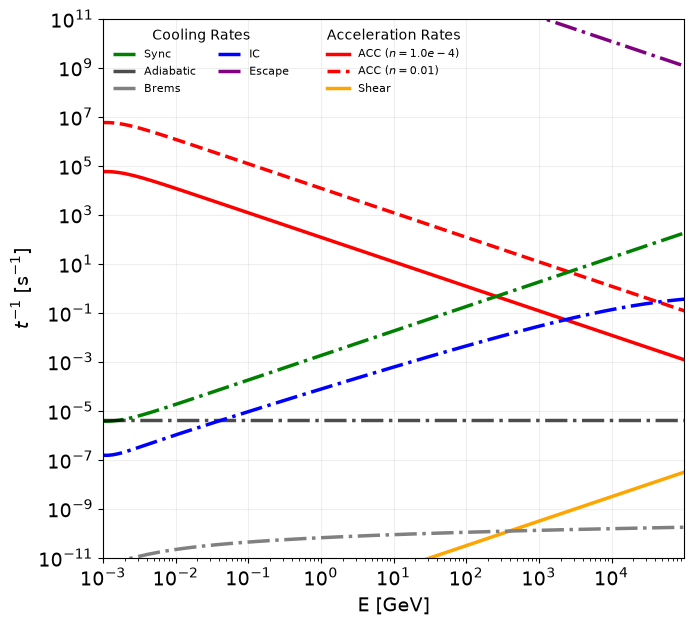

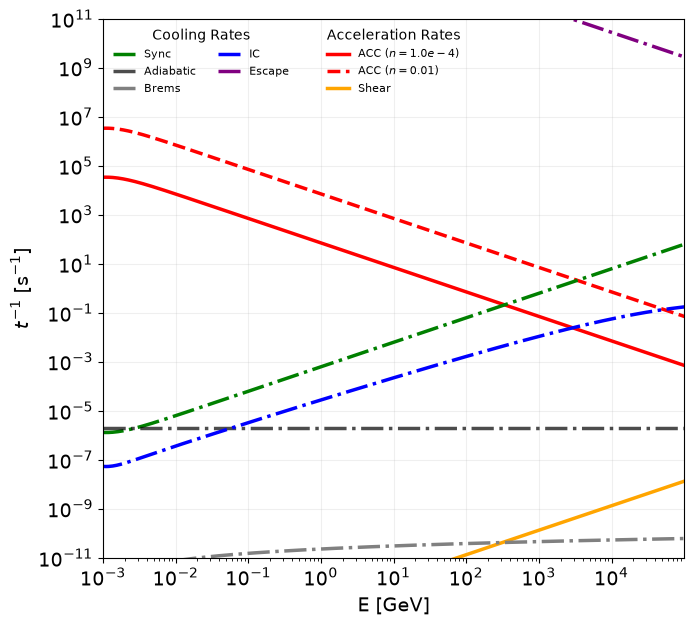

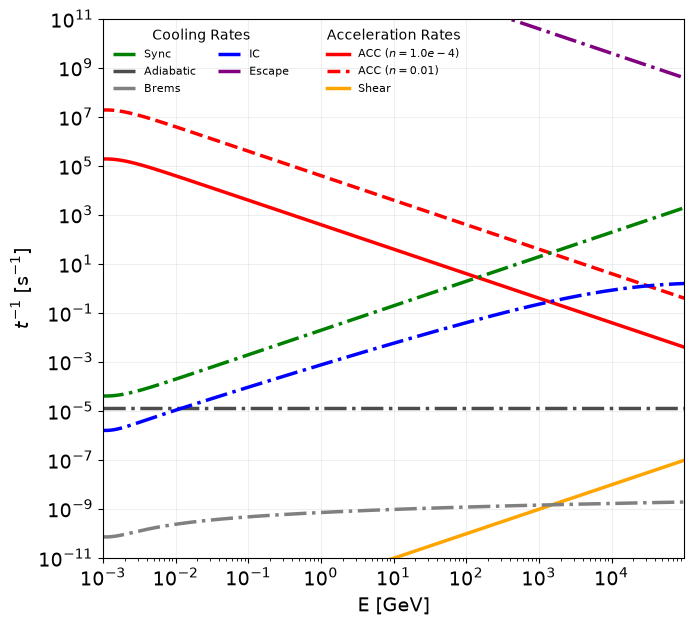

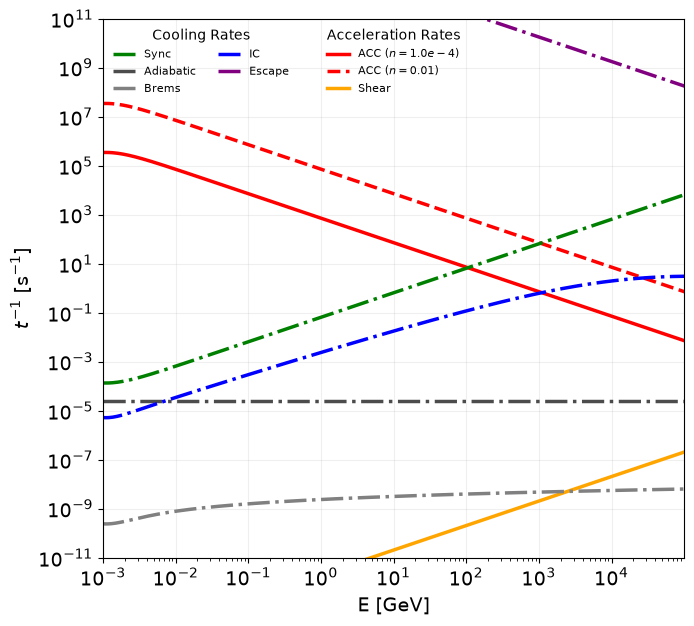

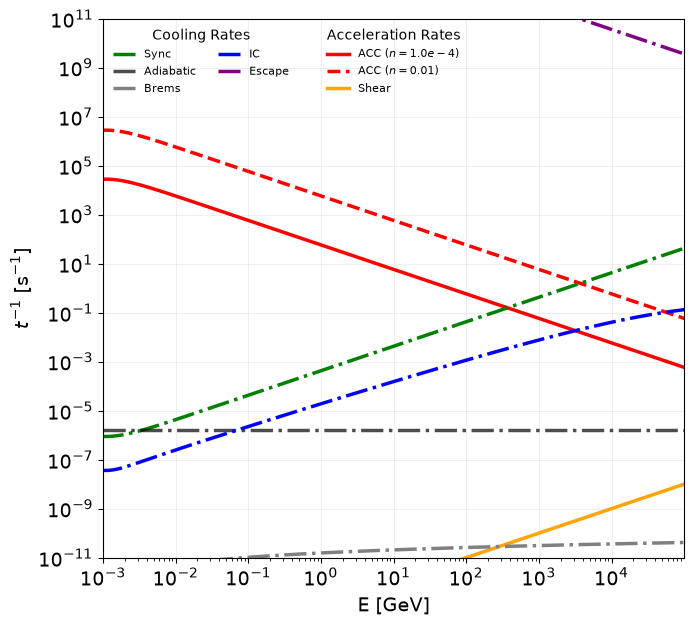

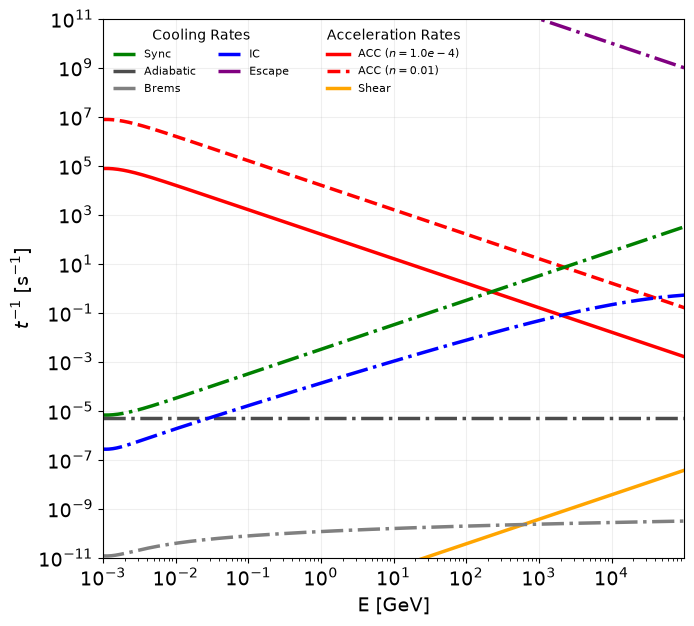

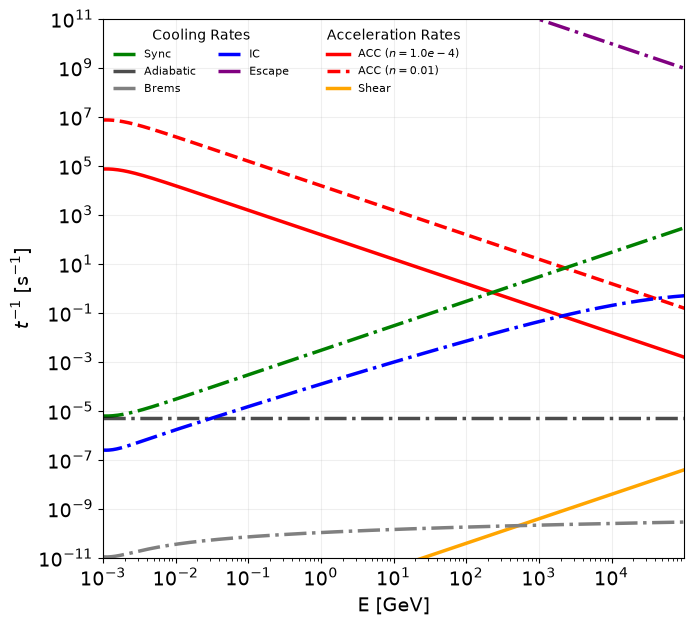

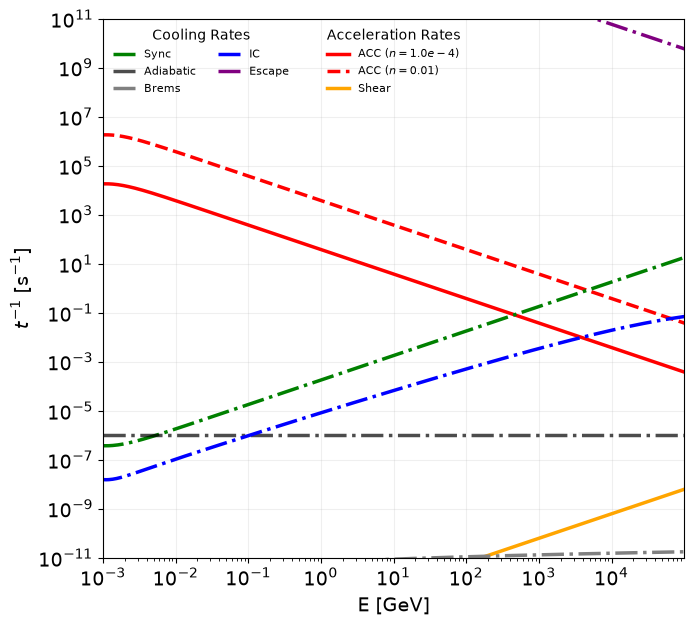

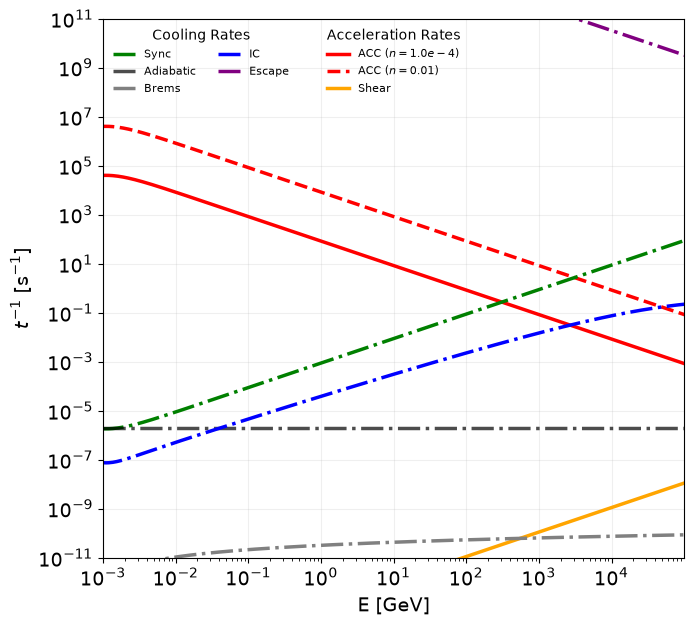

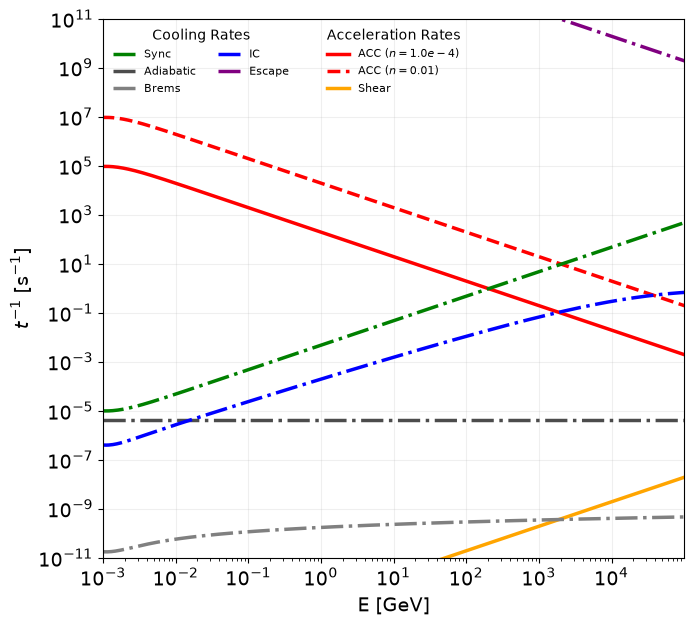

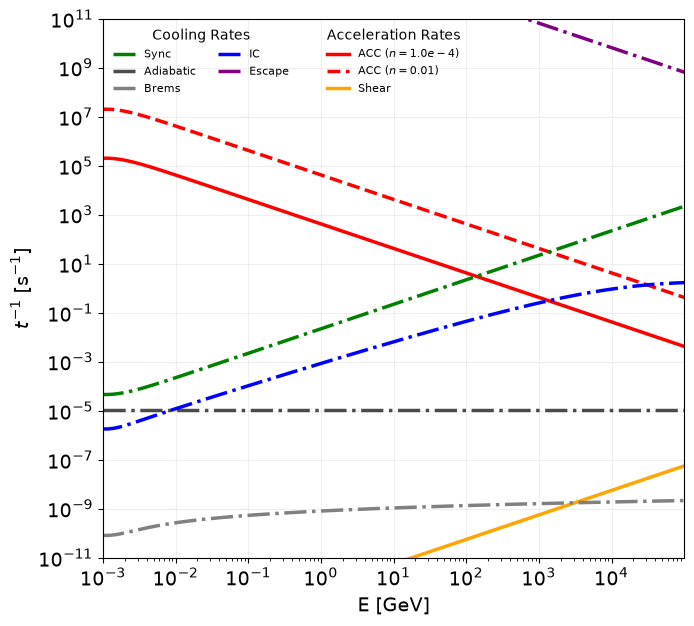

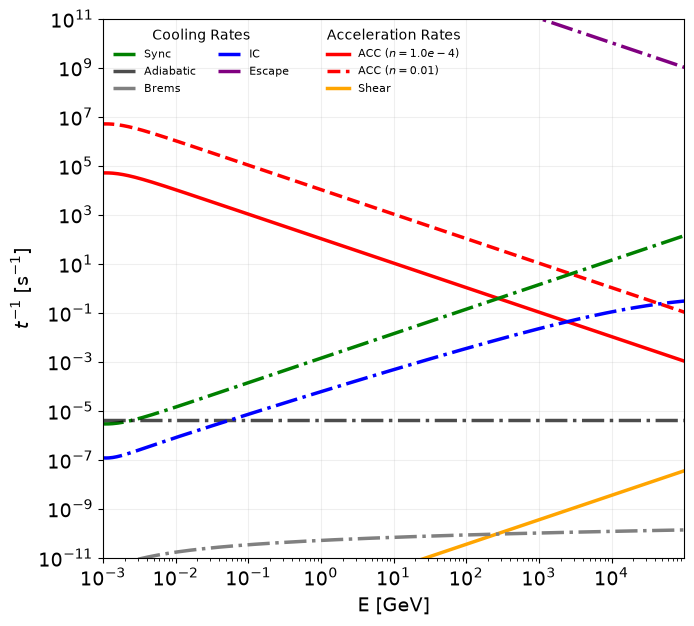

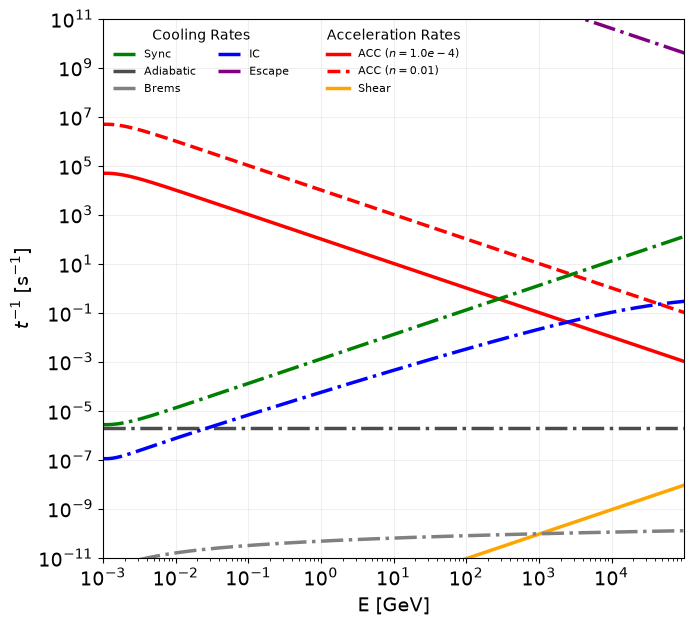

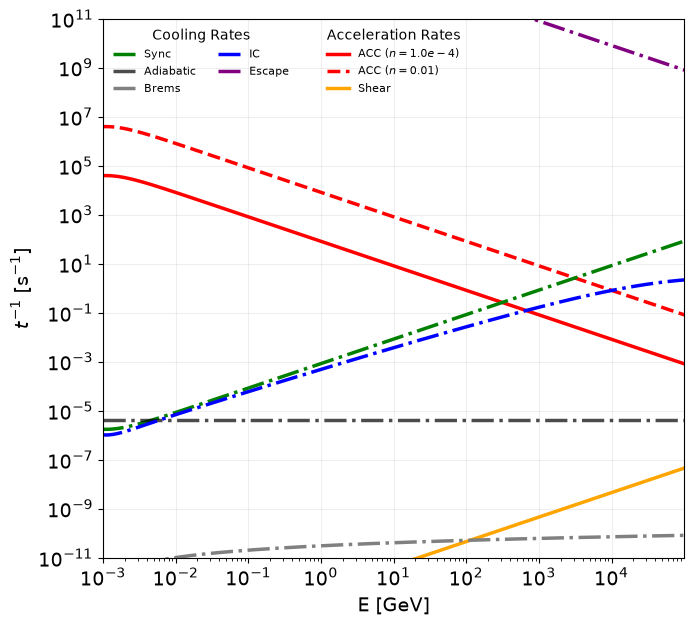

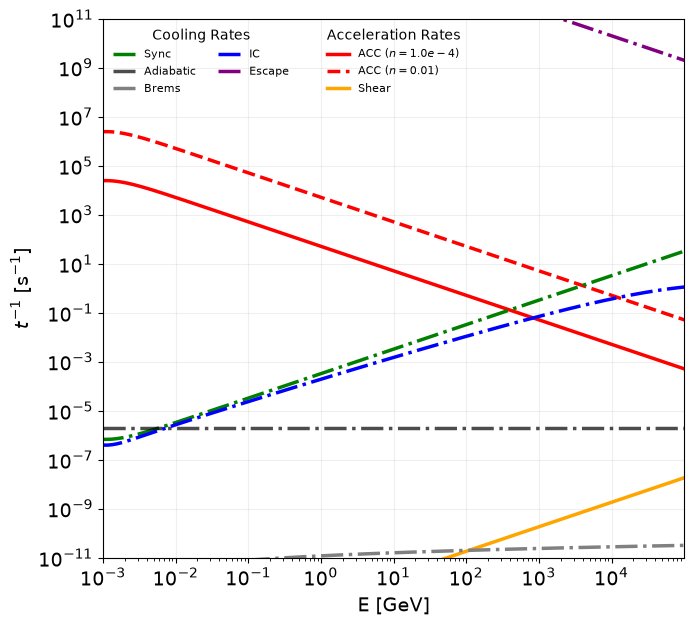

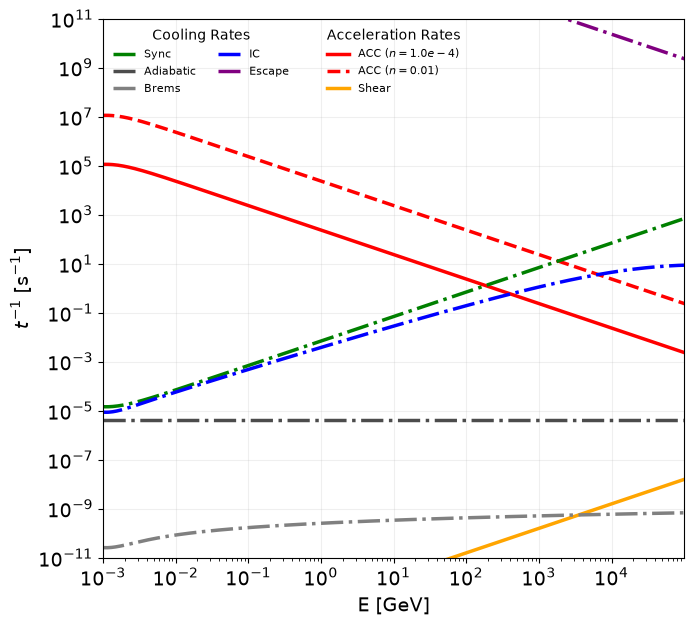

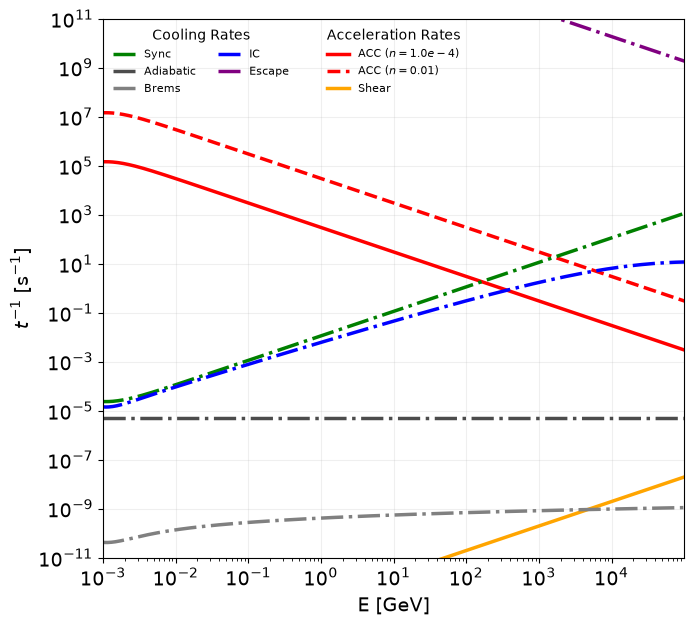

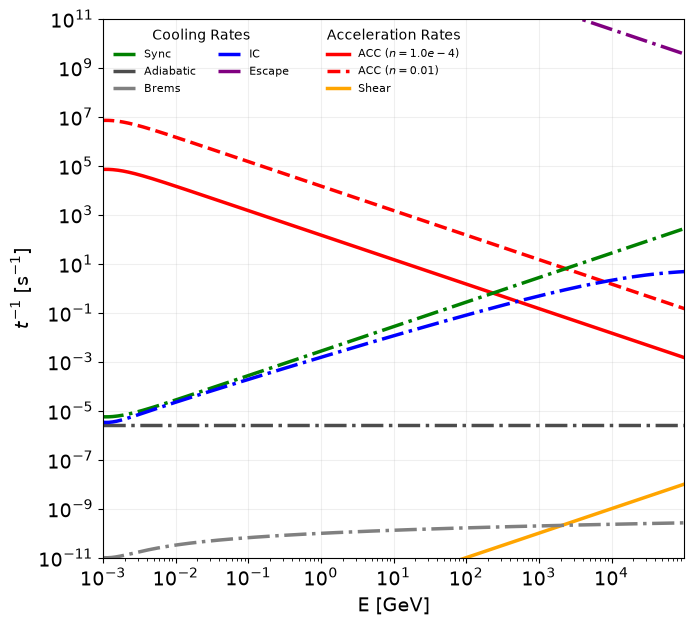

In [ ]:
print("=== PLOTTING ELECTRON GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

# --- Pastas de entrada (ajuste aqui se o run_pipeline salvou em outro lugar) ---
ELECTRON_DIR = "data3_helium"        # pasta com {name}_electrons.csv
HELIUM_DIR   = "data3_helium" # pasta com {name}_oxygen.csv (saida do run_pipeline p/ source.txt)

source_file = "source3.txt"
source_list = []

try:
    with open(source_file, mode='r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            source_list.append(row)
except FileNotFoundError:
    print(f"ERROR: File '{source_file}' not found.")

for params in source_list:
    source_name = params['name']
    filename = f"{ELECTRON_DIR}/{source_name}_electrons.csv"

    # 1. Resgatando os valores de n do seu source.txt
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')

    E_GeV_ele, rate_acc, rate_acc_2, rate_sync, rate_bremss, rate_ic0, rate_ic1 = [], [], [], [], [], [], []
    rate_shear_ele, rate_esc_ele = [], []
    t_ad_val = 0

    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_ele.append(float(row['E_GeV']))
                rate_acc.append(float(row['rate_acc']))
                rate_acc_2.append(float(row['rate_acc_2']))
                rate_sync.append(float(row['rate_sync']))
                rate_bremss.append(float(row['rate_bremss']))
                rate_ic0.append(float(row['rate_ic_0']))
                rate_ic1.append(float(row['rate_ic_1']))
                rate_shear_ele.append(float(row['Shear']))
                rate_esc_ele.append(float(row['ESC']))
                t_ad_val = float(row['t_ad_val'])
    except FileNotFoundError:
        print(f"ERROR: File '{filename}' not found.")
        continue

    plt.figure(figsize=(7.5, 7))

    # 2. Inserindo os valores dinamicamente nas labels usando f-strings
    line_acc, = plt.loglog(E_GeV_ele, rate_acc, label=f'ACC ($n={n_val}$)', color='red', linestyle='-', linewidth=2.5)
    line_acc2, = plt.loglog(E_GeV_ele, rate_acc_2, label=f'ACC ($n={n_2_val}$)', color='red', linestyle='--', linewidth=2.5)

    line_shear, = plt.loglog(E_GeV_ele, rate_shear_ele, label='Shear', color='orange', linestyle='-', linewidth=2.5)

    # Curvas de Resfriamento/Fuga
    line_sync, = plt.loglog(E_GeV_ele, rate_sync, label='Sync', color='green', linestyle='dashdot', linewidth=2.5)
    line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='dashdot', alpha=0.7, linewidth=2.5)
    line_brems, = plt.loglog(E_GeV_ele, rate_bremss, label='Brems', color='grey', linestyle='dashdot', linewidth=2.5)
    line_ic1, = plt.loglog(E_GeV_ele, rate_ic1, label='IC', color='blue', linestyle='dashdot', markerfacecolor='none', linewidth=2.5)
    line_esc, = plt.loglog(E_GeV_ele, rate_esc_ele, label='Escape', color='purple', linestyle='dashdot', linewidth=2.5)

    leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration Rates', loc='upper center', fontsize=8, frameon=False)
    plt.gca().add_artist(leg_acc)
    leg_cool = plt.legend(handles=[line_sync, line_ad, line_brems, line_ic1, line_esc], title='Cooling Rates', loc='upper left', fontsize=8, frameon=False, ncol=2)

    plt.xlabel('E [GeV]', fontsize=14)
    plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
    plt.xlim(1e-3, 1e5)
    plt.ylim(1e-11, 1e11)

    plt.xticks([10.0**i for i in range(-3, 5, 1)])
    plt.yticks([10.0**i for i in range(-11, 12, 2)])
    plt.tick_params(axis='both', which='major', labelsize=14)

    plt.grid(True, which="major", ls="-", alpha=0.2)

    os.makedirs("image", exist_ok=True)

    plt.savefig(f"image/03/{source_name}_electrons.png", bbox_inches='tight')

    plt.show()

print("=== PLOTTING OXYGEN GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

# Garante que a pasta existe para não dar erro no savefig
os.makedirs("image", exist_ok=True)

for params in source_list:
    source_name = params['name']
    filename = f"{HELIUM_DIR}/{source_name}_helium.csv"

    # 1. Resgatando os valores de n para as legendas
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')

    # 2. Listas para os núcleos de Ferro 
    E_GeV_IR, rate_acc_IR, rate_acc_IR_2, rate_sync_IR = [], [], [], []
    rate_IRp, rate_IRg, rate_photodis = [], [], []
    rate_shear_IR, rate_esc_IR = [], []
    t_ad_val = 0

    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_IR.append(float(row['E_prime_GeV_total']))
                rate_acc_IR.append(float(row['rate_acc']))
                rate_acc_IR_2.append(float(row['rate_acc_2']))
                rate_sync_IR.append(float(row['rate_sync']))
                rate_IRp.append(float(row['rate_Hep']))
                rate_IRg.append(float(row['rate_pg']))
                rate_photodis.append(float(row['rate_photodisintegration']))
                rate_shear_IR.append(float(row['Shear']))
                rate_esc_IR.append(float(row['ESC']))
                t_ad_val = float(row['t_ad_val'])

        plt.figure(figsize=(7.5, 7))

        # 3. Curvas de Aceleração (Original e Alternativa) com f-strings
        line_acc, = plt.loglog(E_GeV_IR, rate_acc_IR, label=f'ACC ($n={n_val}$)', color='red', linestyle='-', linewidth=2.5)
        line_acc2, = plt.loglog(E_GeV_IR, rate_acc_IR_2, label=f'ACC ($n={n_2_val}$)', color='darkred', linestyle='--', linewidth=2.5)
        line_shear, = plt.loglog(E_GeV_IR, rate_shear_IR, label='Shear', color='orange', linestyle='-', linewidth=2.5)

        # Curvas de Resfriamento/Fuga (agora para oxigênio)
        line_sync, = plt.loglog(E_GeV_IR, rate_sync_IR, label='Sync', color='green', linestyle='-.', linewidth=2.5)
        line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='-.', alpha=0.7, linewidth=2.5)
        line_Hep, = plt.loglog(E_GeV_IR, rate_IRp, label='Fe-p', color='grey', linestyle='-.', linewidth=2.5)
        line_pg, = plt.loglog(E_GeV_IR, rate_IRg, label='Fe$\\gamma$', color='deeppink', linestyle='-.', linewidth=2.5)
        line_photodis, = plt.loglog(E_GeV_IR, rate_photodis, label='Photodis.', color='saddlebrown', linestyle='-.', linewidth=2.5)
        line_esc, = plt.loglog(E_GeV_IR, rate_esc_IR, label='Escape', color='purple', linestyle='-.', linewidth=2.5)

        # 4. Atualização da legenda de aceleração
        leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration', loc='upper right', fontsize=10, frameon=False)
        plt.gca().add_artist(leg_acc)
        leg_cool = plt.legend(handles=[line_sync, line_ad, line_Hep, line_pg, line_photodis, line_esc], title='Cooling', loc='upper left', fontsize=10, frameon=False, ncol=2)

        plt.xlabel('E [GeV]', fontsize=14)
        plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
        # OBS: a grade de energia do oxigênio (E_GeV_O = logspace(0, 21, 500))
        # cobre uma faixa MUITO maior que a dos prótons antigos (era 1e2-1e10).
        # Ajuste xlim/ylim abaixo depois de olhar seus dados reais.
        plt.xlim(1e2, 1e14)
        plt.ylim(1e-15, 1e9)

        plt.xticks([10.0**i for i in range(2, 15, 2)])
        plt.yticks([10.0**i for i in range(-15, 10, 2)])
        plt.tick_params(axis='both', which='major', labelsize=14)

        plt.grid(True, which="major", ls="-", alpha=0.2)

        plt.savefig(f"image/03/{source_name}_helium.png", bbox_inches='tight')
        plt.show()

    except FileNotFoundError:
        print(f"File {filename} not found for plotting.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import csv
import os

# Directory settings and constants
source_file = "source2.txt"
output_dir = "data2_oxygen"
c = 2.998e10

with open(source_file, mode='r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        source_name = row['name']
        Gamma_b = float(row['Gamma_b'])
        
        E_file = f"{output_dir}/{source_name}_oxygen_E_grid.npy"
        z_file = f"{output_dir}/{source_name}_oxygen_z_grid.npy"
        N_file = f"{output_dir}/{source_name}_oxygen_N_grid.npy"
        
        # Checks if the source files exist
        if not (os.path.exists(E_file) and os.path.exists(z_file) and os.path.exists(N_file)):
            print(f"Files not found for source: {source_name}. Skipping...")
            continue
            
        print(f"Generating plot for source: {source_name} (Gamma_b = {Gamma_b})")
        
        # Loads the data
        E_grid = np.load(E_file)
        z_grid = np.load(z_file)
        N_grid = np.load(N_file)
        
        # Converts Length Scale (z) to Time (t)
        beta = np.sqrt(1 - 1/Gamma_b**2)
        v_b = beta * c
        time_grid = z_grid / v_b
        
        # Creates 2D meshes
        E_mesh, T_mesh = np.meshgrid(E_grid, time_grid, indexing='ij')
        _, Z_mesh = np.meshgrid(E_grid, z_grid, indexing='ij')
        
        fig = plt.figure(figsize=(10, 7))
        
        # Adjusts the subplot margins to make room for the colorbar on the right
        fig.subplots_adjust(left=0.05, right=0.85)
        
        ax = fig.add_subplot(111, projection='3d')
        
        # AXES DEFINITION:
        X = np.log10(E_mesh)   # X-axis = Log(Energy)
        Y = T_mesh             # Y-axis = Time
        Z = Z_mesh             # Z-axis = Length Scale
        
        # Applies Density (N_grid) as the surface COLOR
        N_log = np.log10(N_grid + 1e-300)
        norm = plt.Normalize(N_log.min(), N_log.max())
        colors = cm.viridis(norm(N_log))
        
        # Plots the surface
        surf = ax.plot_surface(X, Y, Z, facecolors=colors, edgecolor='none', shade=False, alpha=0.9)
        
        # Labels
        ax.set_xlabel('Log(Energy) [erg]', labelpad=10)
        ax.set_ylabel('Time [s]', labelpad=10)
        
        # Increased labelpad to push the label away from the tick numbers
        ax.set_zlabel('Length Scale (z) [cm]', labelpad=15)
        
        # Colorbar indicating what the colors represent (Density)
        m = cm.ScalarMappable(cmap='viridis', norm=norm)
        m.set_array([])
        
        # Added pad=0.15 to push the colorbar further to the right, away from the Z-axis
        fig.colorbar(m, ax=ax, shrink=0.5, aspect=10, pad=0.15, label='Log(Density $N$)')
        
        # Title removed as requested
        
# Substitua o plt.show() por:
        
        # Define o caminho e o nome do arquivo da imagem
        image_filename = f"image/{source_name}_3Dplot.png"
        
        # Salva a imagem com alta resolução (dpi=300) e ajusta as margens (bbox_inches='tight')
        plt.savefig(image_filename, dpi=300, bbox_inches='tight')
        
        print(f"Imagem salva em: {image_filename}")
        
        # Fecha a figura para liberar a memória (muito importante ao rodar várias fontes em loop)
        plt.close(fig)